In [109]:
%load_ext autoreload
%autoreload 2

import json
import rootutils
from dotenv import load_dotenv

root = rootutils.setup_root(search_from='..', indicator="pyproject.toml", pythonpath=True, cwd=True)
print(f"Root directory: {root}")
print(f".env file path: {root / '.env'}")
load_dotenv(dotenv_path= root / ".env")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Root directory: /Users/snopoff/Documents/Research/LLMxM2
.env file path: /Users/snopoff/Documents/Research/LLMxM2/.env


True

## The whole dataset

In [34]:
with open(root/"data/processed/realmathbenchmark_full_preprocessed_unified_2026-05-07-20-14.json", "r") as f:
    data = json.load(f)

meta, problems = data["meta"]["totals"], data["results"]
no_error_problems = [p for p in problems if "error" not in p["llm"]]

### Split by complexity and type

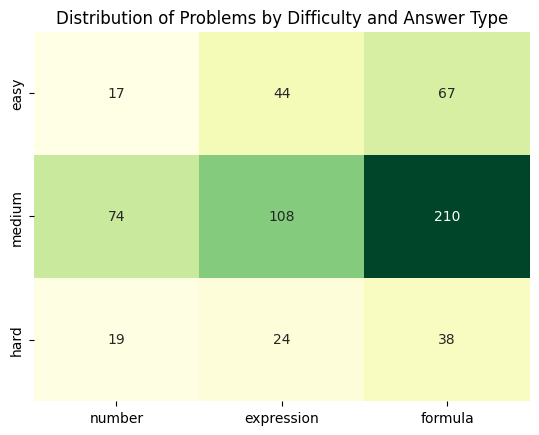

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

distribution_per_difficulty_and_answer = pd.DataFrame(
    [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

problems_by_difficulty = {}
problems_by_type = {}

for difficulty in distribution_per_difficulty_and_answer.index:
    problems_by_difficulty[difficulty] = list(filter(lambda problem: problem["llm"]["difficulty"] == difficulty, no_error_problems))

for answer_type in distribution_per_difficulty_and_answer.columns:
    problems_by_type[answer_type] = list(filter(lambda problem: problem["llm"]["answer_type"] == answer_type, no_error_problems))

for difficulty in distribution_per_difficulty_and_answer.index:
    for answer_type in distribution_per_difficulty_and_answer.columns:
        distribution_per_difficulty_and_answer.loc[difficulty, answer_type] = len([
            problem for problem in problems_by_difficulty[difficulty] if problem in problems_by_type[answer_type]
        ])

ax = sns.heatmap(distribution_per_difficulty_and_answer, annot=True, fmt="d", cmap="YlGn", cbar=False)
ax.set_title("Distribution of Problems by Difficulty and Answer Type")
plt.show()

Text(0.5, 1.0, 'Median Length of (Original) Question by Difficulty and Answer Type')

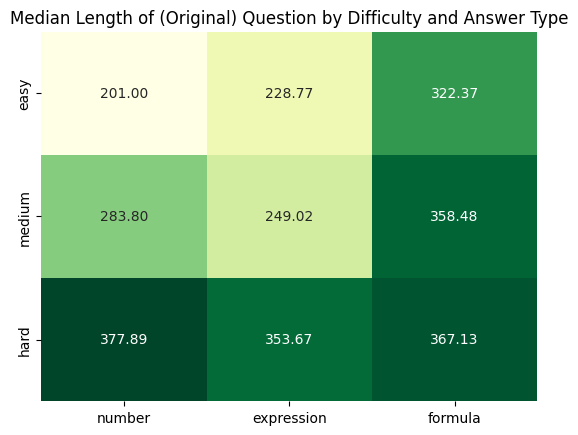

In [40]:
median_length_of_original_question_per_difficulty_and_answer = pd.DataFrame(
    [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

for difficulty in median_length_of_original_question_per_difficulty_and_answer.index:
    for answer_type in median_length_of_original_question_per_difficulty_and_answer.columns:
        median_length_of_original_question_per_difficulty_and_answer.loc[difficulty, answer_type] = sum([
            len(problem["question"])
            for problem in problems_by_difficulty[difficulty]
            if problem in problems_by_type[answer_type]
        ]) / distribution_per_difficulty_and_answer.loc[difficulty, answer_type]

ax = sns.heatmap(median_length_of_original_question_per_difficulty_and_answer, annot=True, fmt=".2f", cmap="YlGn", cbar=False)
ax.set_title("Median Length of (Original) Question by Difficulty and Answer Type")

Text(0.5, 1.0, 'Median Length of (Revised) Question by Difficulty and Answer Type')

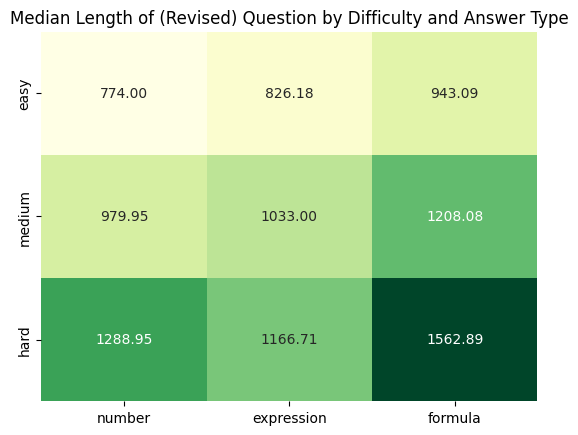

In [41]:
median_length_of_revised_question_per_difficulty_and_answer = pd.DataFrame(
    [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

for difficulty in median_length_of_revised_question_per_difficulty_and_answer.index:
    for answer_type in median_length_of_revised_question_per_difficulty_and_answer.columns:
        median_length_of_revised_question_per_difficulty_and_answer.loc[difficulty, answer_type] = sum([
            len(problem["llm"]["revised_question"])
            for problem in problems_by_difficulty[difficulty]
            if problem in problems_by_type[answer_type]
        ]) / distribution_per_difficulty_and_answer.loc[difficulty, answer_type]

ax = sns.heatmap(median_length_of_revised_question_per_difficulty_and_answer, annot=True, fmt=".2f", cmap="YlGn", cbar=False)
ax.set_title("Median Length of (Revised) Question by Difficulty and Answer Type")

### Save datasets

In [45]:
for difficulty in problems_by_difficulty:
    print(f"{difficulty}: {len(problems_by_difficulty[difficulty])} problems")
    json.dump(problems_by_difficulty[difficulty], open(root/f"data/processed/problems_by_difficulty_{difficulty}.json", "w"), indent=4)

for answer_type in problems_by_type:
    print(f"{answer_type}: {len(problems_by_type[answer_type])} problems")
    json.dump(problems_by_type[answer_type], open(root/f"data/processed/problems_by_answer_type_{answer_type}.json", "w"), indent=4)

easy: 128 problems
medium: 392 problems
hard: 81 problems
number: 110 problems
expression: 176 problems
formula: 315 problems


## Normalized dataset

In [68]:
with open(root/"data/processed/normalized_problems.json", "r") as f:
    normalized_problems = json.load(f)

normalized_problems_by_difficulty = {}
normalized_problems_by_type = {}

for key, value in problems_by_difficulty.items():
    normalized_problems_by_difficulty[key] = [problem for problem in normalized_problems if problem["id"] in [p["id"] for p in value]]

for key, value in problems_by_type.items():
    normalized_problems_by_type[key] = [problem for problem in normalized_problems if problem["id"] in [p["id"] for p in value]]

In [69]:
print("Problems by difficulty (normalized):")
for difficulty in normalized_problems_by_difficulty:
    print(f"{difficulty}: {len(normalized_problems_by_difficulty[difficulty])} problems")
    if len(normalized_problems_by_difficulty[difficulty]) > 0:
        json.dump(normalized_problems_by_difficulty[difficulty], open(root/f"data/processed/normalized_problems_by_difficulty_{difficulty}.json", "w"), indent=4)

print("\nProblems by answer type (normalized):")
for answer_type in normalized_problems_by_type:
    print(f"{answer_type}: {len(normalized_problems_by_type[answer_type])} problems")
    if len(normalized_problems_by_type[answer_type]) > 0:
        json.dump(normalized_problems_by_type[answer_type], open(root/f"data/processed/normalized_problems_by_type_{answer_type}.json", "w"), indent=4)

Problems by difficulty (normalized):
easy: 0 problems
medium: 179 problems
hard: 40 problems

Problems by answer type (normalized):
number: 93 problems
expression: 126 problems
formula: 0 problems


## Comparison DeepSeek No Tool

In [255]:
with open(root/"data/results/deepseek/no_tool/deepseekv32_medium_hard_number_expression.json", "r") as f:
    no_tool_deepseekv32 = json.load(f)

In [ ]:
##! OLD

answers_by_difficulty = {}
answers_by_type = {}

for difficulty in normalized_problems_by_difficulty:
    answers_by_difficulty[difficulty] = [
        answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
    ]

for answer_type in normalized_problems_by_type:
    answers_by_type[answer_type] = [
        answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
    ]

print("Answers by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"  {difficulty}: {len(answers)}")
    #with open(root/f"data/results/predictions_no_tool_deepseekv32_{difficulty}_number_expression.json", "w") as f:
    #    json.dump(answers, f, indent=4)

print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"  {answer_type}: {len(answers)}")
    #with open(root/f"data/results/predictions_no_tool_deepseekv32_medium_hard_{answer_type}.json", "w") as f:
    #    json.dump(answers, f, indent=4)

Answers by difficulty:
  easy: 0
  medium: 179
  hard: 40

Answers by answer type:
  number: 93
  expression: 126
  formula: 0


In [ ]:
for difficulty in normalized_problems_by_difficulty:
    for answer_type in normalized_problems_by_type:
        difficulty_answer_type_results = [
            answer for answer in no_tool_deepseekv32
            if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
            and answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
        ]
        count = len(difficulty_answer_type_results)
        print(f"{difficulty} - {answer_type}: {count} answers")
        if count > 0:
            with open(root/f"data/results/deepseek/no_tool/deepseekv32_{difficulty}_{answer_type}.json", "w") as f:
                json.dump(difficulty_answer_type_results, f, indent=4)
                print(f"Saved {count} answers for difficulty '{difficulty}' and answer type '{answer_type}' to {f.name}")


easy - number: 0 answers
easy - expression: 0 answers
easy - formula: 0 answers
medium - number: 74 answers
Saved 74 answers for difficulty 'medium' and answer type 'number' to /Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_medium_number.json
medium - expression: 105 answers
Saved 105 answers for difficulty 'medium' and answer type 'expression' to /Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_medium_expression.json
medium - formula: 0 answers
hard - number: 19 answers
Saved 19 answers for difficulty 'hard' and answer type 'number' to /Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_hard_number.json
hard - expression: 21 answers
Saved 21 answers for difficulty 'hard' and answer type 'expression' to /Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_hard_expression.json
hard - formula: 0 answers


In [180]:
from src.benchmark.compare_predictions import compare_predictions, ComparePredictionsConfig

compare_predictions_config = ComparePredictionsConfig(
    root/"data/results/deepseek/no_tool/deepseekv32_medium_hard_number_expression.json",
    summary_path=root/"data/results/deepseek/no_tool/deepseekv32_medium_hard_number_expression.json")

compare_predictions(compare_predictions_config)

Symbolic match for problem ID realmathbenchmark-00145
Symbolic match for problem ID realmathbenchmark-00178
Symbolic match for problem ID realmathbenchmark-00484
Symbolic match for problem ID realmathbenchmark-00507
Symbolic match for problem ID realmathbenchmark-00508


{'rows': 219,
 'accuracy': 0.223744,
 'correct': 49,
 'incorrect': 170,
 'exact_correct': 44,
 'symbolic_correct': 5,
 'missing_prediction_rows': 7,
 'missing_reference_rows': 0,
 'timed_out_rows': 0,
 'malformed_rows_skipped': 0,
 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_medium_hard_number_expression.json',
 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_medium_hard_number_expression_comparison_2026-05-17-01-59.json',
 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/comparison/deepseekv32_medium_hard_number_expression.json',
 'per_row_timeout_sec': 2.0,
 'prediction_sympy_fields': ['model_sympy_answer',
  'predicted_sympy_answer',
  'sympy_answer'],
 'reference_sympy_fields': ['ground_truth_sympy_answer',
  'reference_sympy_answer',
  'sympy_answer']}

In [261]:
for difficulty in normalized_problems_by_difficulty:
    for answer_type in normalized_problems_by_type:
        print(f"\nComparing predictions for difficulty '{difficulty}' and answer type '{answer_type}':")
        try:
            compare_predictions_config = ComparePredictionsConfig(
            root/f"data/results/deepseek/no_tool/deepseekv32_{difficulty}_{answer_type}.json",
            summary_path=root/f"data/results/deepseek/no_tool/comparison/deepseekv32_{difficulty}_{answer_type}.json",
            output_path=root/f"data/results/deepseek/no_tool/output/deepseekv32_{difficulty}_{answer_type}.json"
            )
            print(compare_predictions(compare_predictions_config))
        except Exception as e:
            print(f"No predictions to compare for difficulty '{difficulty}' and answer type '{answer_type}': {e}")


Comparing predictions for difficulty 'easy' and answer type 'number':
No predictions to compare for difficulty 'easy' and answer type 'number': [Errno 2] No such file or directory: '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_easy_number.json'

Comparing predictions for difficulty 'easy' and answer type 'expression':
No predictions to compare for difficulty 'easy' and answer type 'expression': [Errno 2] No such file or directory: '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_easy_expression.json'

Comparing predictions for difficulty 'easy' and answer type 'formula':
No predictions to compare for difficulty 'easy' and answer type 'formula': [Errno 2] No such file or directory: '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_easy_formula.json'

Comparing predictions for difficulty 'medium' and answer type 'number':
Symbolic match for problem ID realmathbenchmark-00507
{'rows

In [ ]:
##! OLD

print("Comparison by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"\n{difficulty}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/no_tool/deepseekv32_{difficulty}_number_expression.json",
        summary_path=root/f"data/results/deepseek/no_tool/comparison/deepseekv32_{difficulty}_number_expression.json",
        output_path=root/f"data/results/deepseek/no_tool/output/deepseekv32_{difficulty}_number_expression.json"
    )
    print(compare_predictions(compare_predictions_config))


print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"\n{answer_type}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/no_tool/deepseekv32_medium_hard_{answer_type}.json",
        summary_path=root/f"data/results/deepseek/no_tool/comparison/deepseekv32_medium_hard_{answer_type}.json",
        output_path=root/f"data/results/deepseek/no_tool/output/deepseekv32_medium_hard_{answer_type}.json"
    )
    print(compare_predictions(compare_predictions_config))

Comparison by difficulty:

easy
  No answers to compare.

medium
  No answers to compare.

hard
{'rows': 40, 'accuracy': 0.2, 'correct': 8, 'incorrect': 32, 'exact_correct': 8, 'symbolic_correct': 0, 'missing_prediction_rows': 2, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/deepseekv32_hard_number_expression.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/output/deepseekv32_hard_number_expression.json', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/comparison/deepseekv32_hard_number_expression.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 'sympy_answer']}

Answers by answer type:

number
Symbolic match for problem ID rea

In [103]:
no_tool_deepseekv32_hard_number = [
    answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty["hard"]] and answer["id"] in [p["id"] for p in normalized_problems_by_type["number"]]
    ]

print(f"Number of hard problems with number answers: {len(no_tool_deepseekv32_hard_number)}")
json.dump(no_tool_deepseekv32_hard_number, open(root/f"data/results/predictions_no_tool_deepseekv32_hard_number.json", "w"), indent=4)

no_tool_deepseekv32_hard_expression = [
    answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty["hard"]] and answer["id"] in [p["id"] for p in normalized_problems_by_type["expression"]]
    ]
print(f"Number of hard problems with expression answers: {len(no_tool_deepseekv32_hard_expression)}")
json.dump(no_tool_deepseekv32_hard_expression, open(root/f"data/results/predictions_no_tool_deepseekv32_hard_expression.json", "w"), indent=4)
print("\nComparison for hard problems with number answers:")
compare_predictions_config = ComparePredictionsConfig(
    root/f"data/results/predictions_no_tool_deepseekv32_hard_number.json",
    summary_path=root/f"data/results/comparison/comparison_no_tool_deepseekv32_hard_number.json")
print(compare_predictions(compare_predictions_config))
print("\nComparison for hard problems with expression answers:")
compare_predictions_config = ComparePredictionsConfig(
    root/f"data/results/predictions_no_tool_deepseekv32_hard_expression.json",
    summary_path=root/f"data/results/comparison/comparison_no_tool_deepseekv32_hard_expression.json")
print(compare_predictions(compare_predictions_config))

Number of hard problems with number answers: 19
Number of hard problems with expression answers: 21

Comparison for hard problems with number answers:
{'rows': 19, 'accuracy': 0.368421, 'correct': 7, 'incorrect': 12, 'exact_correct': 7, 'symbolic_correct': 0, 'missing_prediction_rows': 0, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_hard_number.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_hard_number_comparison_2026-05-16-20-52.jsonl', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/comparison/comparison_no_tool_deepseekv32_hard_number.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 'sympy_answer']}

Comparis

## Comparison DeepSeek with Sage

In [ ]:
with open(root/"data/results/deepseek/tool/predictions_sage_deepseekv32_hard_number_expression.json", "r") as f:
    sage_deepseekv32 = json.load(f)

In [123]:
answers_by_difficulty = {}
answers_by_type = {}

for difficulty in normalized_problems_by_difficulty:
    answers_by_difficulty[difficulty] = [
        answer for answer in sage_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
    ]

for answer_type in normalized_problems_by_type:
    answers_by_type[answer_type] = [
        answer for answer in sage_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
    ]

print("Answers by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"  {difficulty}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/predictions_sage_deepseekv32_{difficulty}_number_expression.json", "w") as f:
        json.dump(answers, f, indent=4)

print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"  {answer_type}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/predictions_sage_deepseekv32_medium_hard_{answer_type}.json", "w") as f:
        json.dump(answers, f, indent=4)

Answers by difficulty:
  easy: 0
  No answers to save.
  medium: 0
  No answers to save.
  hard: 40

Answers by answer type:
  number: 19
  expression: 21
  formula: 0
  No answers to save.


In [131]:
print("Comparison by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"\n{difficulty}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/sage_deepseekv32_{difficulty}_number_expression.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/sage_deepseekv32_{difficulty}_number_expression.json",
        output_path=root/f"data/results/deepseek/tool/output/sage_deepseekv32_{difficulty}_number_expression.json"
        )
    print(compare_predictions(compare_predictions_config))


print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"\n{answer_type}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/sage_deepseekv32_hard_{answer_type}.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/sage_deepseekv32_hard_{answer_type}.json",
        output_path=root/f"data/results/deepseek/tool/output/sage_deepseekv32_hard_{answer_type}.json"
        )
    print(compare_predictions(compare_predictions_config))

Comparison by difficulty:

easy
  No answers to compare.

medium
  No answers to compare.

hard
{'rows': 40, 'accuracy': 0.3, 'correct': 12, 'incorrect': 28, 'exact_correct': 12, 'symbolic_correct': 0, 'missing_prediction_rows': 2, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/sage_deepseekv32_hard_number_expression.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/output/sage_deepseekv32_hard_number_expression.json', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/comparison/sage_deepseekv32_hard_number_expression.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 'sympy_answer']}

Answers by answer type:

number
{'rows': 19, 'accuracy': 

## Statistics of comparison

In [239]:
with open(root/"data/results/deepseek/tool/output/sage_deepseekv32_medium_number_expression_0_60.json", "r") as f:
    sage_deepseekv32_comparison = json.load(f)

TYPE_OF_PROBLEMS = "Medium"

In [240]:
incorrect = [item for item in sage_deepseekv32_comparison if not item["correct"]]
correct = [item for item in sage_deepseekv32_comparison if item["correct"]]

In [241]:
number_ids = [p["id"] for p in answers_by_type["number"]]
expression_ids = [p["id"] for p in answers_by_type["expression"]]

stats = {
    "tool_traces_errors_for_incorrect": [len(list(filter(lambda x: x["metadata"]["status"] == "error", item["tool_traces"]))) for item in incorrect],
    "tool_traces_total_for_incorrect": [len(item["tool_traces"]) for item in incorrect],
    "tool_traces_errors_for_correct": [len(list(filter(lambda x: x["metadata"]["status"] == "error", item["tool_traces"]))) for item in correct],
    "tool_traces_total_for_correct": [len(item["tool_traces"]) for item in correct],
    "tool_traces_errors_for_number": [len(list(filter(lambda x: x["metadata"]["status"] == "error", item["tool_traces"]))) for item in sage_deepseekv32_comparison if item["id"] in number_ids],
    "tool_traces_errors_for_expression": [len(list(filter(lambda x: x["metadata"]["status"] == "error", item["tool_traces"]))) for item in sage_deepseekv32_comparison if item["id"] in expression_ids],
    "tool_traces_total_for_number": [len(item["tool_traces"]) for item in sage_deepseekv32_comparison if item["id"] in number_ids],
    "tool_traces_total_for_expression": [len(item["tool_traces"]) for item in sage_deepseekv32_comparison if item["id"] in expression_ids]
}

In [242]:
len(stats["tool_traces_errors_for_incorrect"]) + len(stats["tool_traces_errors_for_correct"])

60

In [243]:
len(stats["tool_traces_errors_for_number"] + stats["tool_traces_errors_for_expression"])

60

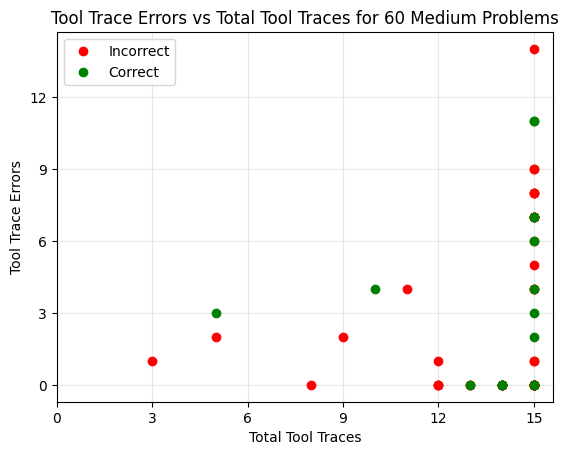

In [244]:
plt.plot(stats["tool_traces_total_for_incorrect"], stats["tool_traces_errors_for_incorrect"], "ro", label="Incorrect")
plt.plot(stats["tool_traces_total_for_correct"], stats["tool_traces_errors_for_correct"], "go", label="Correct")
plt.xlabel("Total Tool Traces")
plt.xticks(range(0,16,3))
plt.ylabel("Tool Trace Errors")
plt.yticks(range(0,13,3))
plt.title(f"Tool Trace Errors vs Total Tool Traces for {len(sage_deepseekv32_comparison)} {TYPE_OF_PROBLEMS} Problems")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

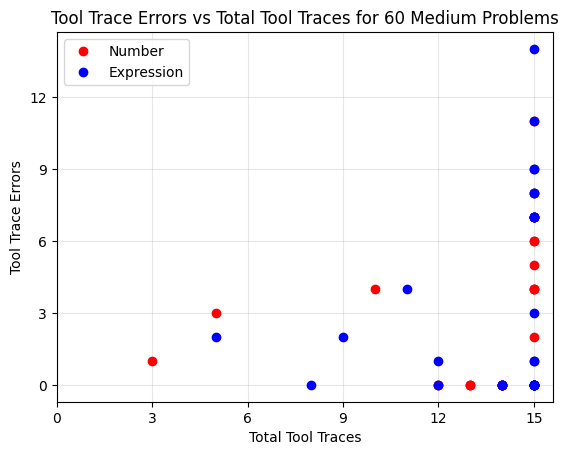

In [245]:
plt.plot(stats["tool_traces_total_for_number"], stats["tool_traces_errors_for_number"], "ro", label="Number")
plt.plot(stats["tool_traces_total_for_expression"], stats["tool_traces_errors_for_expression"], "bo", label="Expression")
plt.xlabel("Total Tool Traces")
plt.xticks(range(0,16,3))
plt.ylabel("Tool Trace Errors")
plt.yticks(range(0,13,3))
plt.title(f"Tool Trace Errors vs Total Tool Traces for {len(sage_deepseekv32_comparison)} {TYPE_OF_PROBLEMS} Problems")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## On Medium Problems

In [248]:
with open(root/"data/results/deepseek/tool/sage_deepseekv32_medium_number_expression_0_60.json", "r") as f:
    sage_deepseekv32_medium_60 = json.load(f)

In [249]:
len(sage_deepseekv32_medium_60)

60

In [253]:
answers_by_difficulty = {}
answers_by_type = {}

for difficulty in normalized_problems_by_difficulty:
    answers_by_difficulty[difficulty] = [
        answer for answer in sage_deepseekv32_medium_60 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
    ]

for answer_type in normalized_problems_by_type:
    answers_by_type[answer_type] = [
        answer for answer in sage_deepseekv32_medium_60 if answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
    ]

print("Answers by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"  {difficulty}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/sage_deepseekv32_{difficulty}_number_expression_0_60.json", "w") as f:
        json.dump(answers, f, indent=4)

print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"  {answer_type}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/sage_deepseekv32_medium_{answer_type}_0_60.json", "w") as f:
        json.dump(answers, f, indent=4)

Answers by difficulty:
  easy: 0
  No answers to save.
  medium: 60
  hard: 0
  No answers to save.

Answers by answer type:
  number: 26
  expression: 34
  formula: 0
  No answers to save.


In [254]:
print("Comparison by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"\n{difficulty}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/sage_deepseekv32_{difficulty}_number_expression_0_60.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/sage_deepseekv32_{difficulty}_number_expression_0_60.json",
        output_path=root/f"data/results/deepseek/tool/output/sage_deepseekv32_{difficulty}_number_expression_0_60.json"
        )
    print(compare_predictions(compare_predictions_config))


print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"\n{answer_type}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/sage_deepseekv32_medium_{answer_type}_0_60.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/sage_deepseekv32_medium_{answer_type}_0_60.json",
        output_path=root/f"data/results/deepseek/tool/output/sage_deepseekv32_medium_{answer_type}_0_60.json"
        )
    print(compare_predictions(compare_predictions_config))

Comparison by difficulty:

easy
  No answers to compare.

medium
Symbolic match for problem ID realmathbenchmark-00043
Symbolic match for problem ID realmathbenchmark-00078
Symbolic match for problem ID realmathbenchmark-00127
Symbolic match for problem ID realmathbenchmark-00134
Symbolic match for problem ID realmathbenchmark-00211
{'rows': 60, 'accuracy': 0.35, 'correct': 21, 'incorrect': 39, 'exact_correct': 16, 'symbolic_correct': 5, 'missing_prediction_rows': 5, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/sage_deepseekv32_medium_number_expression_0_60.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/output/sage_deepseekv32_medium_number_expression_0_60.json', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/comparison/sage_deepseekv32_medium_number_expression_0_60.json', 'per_row_timeout_

In [220]:
[p["id"] for p in normalized_problems_by_difficulty["medium"]]

['realmathbenchmark-00006',
 'realmathbenchmark-00007',
 'realmathbenchmark-00013',
 'realmathbenchmark-00019',
 'realmathbenchmark-00020',
 'realmathbenchmark-00021',
 'realmathbenchmark-00024',
 'realmathbenchmark-00029',
 'realmathbenchmark-00041',
 'realmathbenchmark-00043',
 'realmathbenchmark-00044',
 'realmathbenchmark-00052',
 'realmathbenchmark-00055',
 'realmathbenchmark-00056',
 'realmathbenchmark-00061',
 'realmathbenchmark-00066',
 'realmathbenchmark-00070',
 'realmathbenchmark-00071',
 'realmathbenchmark-00078',
 'realmathbenchmark-00084',
 'realmathbenchmark-00088',
 'realmathbenchmark-00092',
 'realmathbenchmark-00093',
 'realmathbenchmark-00096',
 'realmathbenchmark-00100',
 'realmathbenchmark-00102',
 'realmathbenchmark-00108',
 'realmathbenchmark-00109',
 'realmathbenchmark-00112',
 'realmathbenchmark-00116',
 'realmathbenchmark-00118',
 'realmathbenchmark-00127',
 'realmathbenchmark-00133',
 'realmathbenchmark-00134',
 'realmathbenchmark-00140',
 'realmathbenchmark-

In [224]:
ids_of_correct_but_evaluated_wrong = ["00080", "00227", "00067", "00123", "00181", "00579", "00219", "00142", "00425", "00044", "00078", "00116", "00171"]
for id in ids_of_correct_but_evaluated_wrong:
    str_id = "realmathbenchmark-" + id
    for difficulty in normalized_problems_by_difficulty:
        if str_id in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]:
            print(f"Problem {str_id} is in difficulty {difficulty}")
    for answer_type in normalized_problems_by_type:
        if str_id in [p["id"] for p in normalized_problems_by_type[answer_type]]:
            print(f"Problem {str_id} is of answer type {answer_type}")
    print()

Problem realmathbenchmark-00080 is in difficulty hard
Problem realmathbenchmark-00080 is of answer type expression

Problem realmathbenchmark-00227 is in difficulty hard
Problem realmathbenchmark-00227 is of answer type expression

Problem realmathbenchmark-00067 is in difficulty hard
Problem realmathbenchmark-00067 is of answer type number

Problem realmathbenchmark-00123 is in difficulty hard
Problem realmathbenchmark-00123 is of answer type expression

Problem realmathbenchmark-00181 is in difficulty hard
Problem realmathbenchmark-00181 is of answer type number

Problem realmathbenchmark-00579 is in difficulty hard
Problem realmathbenchmark-00579 is of answer type expression

Problem realmathbenchmark-00219 is in difficulty hard
Problem realmathbenchmark-00219 is of answer type expression

Problem realmathbenchmark-00142 is in difficulty hard
Problem realmathbenchmark-00142 is of answer type expression

Problem realmathbenchmark-00425 is in difficulty hard
Problem realmathbenchmark-